# AlexNet vs Vision Transformer on Tiny ImageNet (600s budget)

This notebook compares AlexNet and ViT using the same 600-second training budget on Tiny ImageNet-200.

Settings are based on the validation notebooks:
- `validation_alexnet.ipynb`: best AlexNet setup (`k3-s1-p1`)
- `validation_vision_transformers.ipynb`: Tiny ViT setup (`64x64`, patch `8`, depth `6`, heads/dropout/mlp = `8 / 0.0 / 4.0`)

Run the code cell below (after the optional git cell).

In [ ]:
import os

REPO_NAME = "4803_project_advanced_neural_networks"
REPO_URL = "https://github.com/zarcop/4803_project_advanced_neural_networks"
if not os.path.isdir(REPO_NAME):
    !git clone {REPO_URL}
else:
    !git -C {REPO_NAME} pull

Device: cuda
Tiny ImageNet root: /content/4803_project_advanced_neural_networks/model/data/tiny-imagenet-200
Train samples: 100000 | Val: 10000 | Classes: 200
AlexNet4803 Tiny ImageNet-200 (600s)
Vision_Transformers Tiny ImageNet-200 (600s)

Comparison @ fixed wall time 600s (Tiny ImageNet-200)


,Model,Params,GFLOPs / forward,Samples @ T=600s,Total GFLOPs,Train Acc (%),Val Acc (%),Val gap (Train-Val) (%),Efficiency (ValAcc / Total GFLOPs),Gen. eff. ((2*Val-Train) / Total GFLOPs)
0,AlexNet4803,58539144,2.009254,280896,564391.523942,9.298,11.12,-1.822,0.000020,0.000023
1,Vision_Transformers,1248840,0.107097,668992,71647.095095,31.415,27.59,3.825,0.000385,0.000332


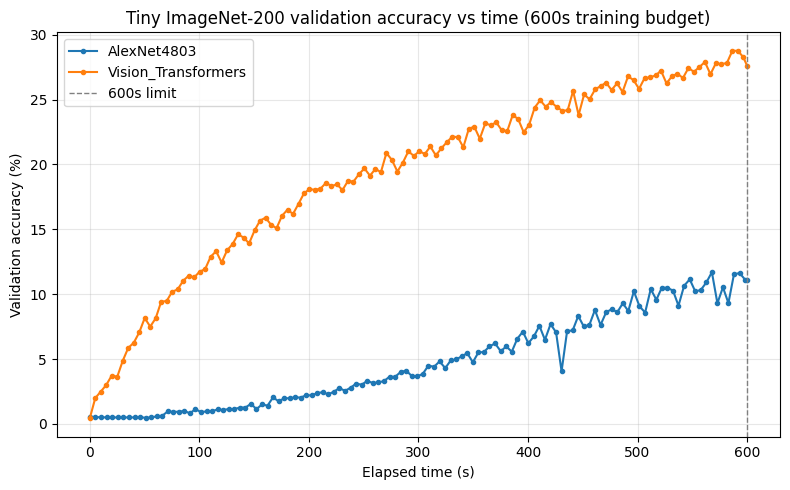

In [2]:
try:
    from thop import profile as thop_profile
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "thop", "-q"])
    from thop import profile as thop_profile

import importlib.util
import sys
import time
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
try:
    from IPython.display import display
except ImportError:

    def display(obj):
        print(obj.to_string() if hasattr(obj, "to_string") else obj)

import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

_here = Path.cwd().resolve()
if (_here / "alexnet.py").exists():
    MODEL_DIR = _here
elif (_here / "model" / "alexnet.py").exists():
    MODEL_DIR = _here / "model"
else:
    MODEL_DIR = Path("/content/4803_project_advanced_neural_networks/model")
    if not MODEL_DIR.exists():
        raise FileNotFoundError(f"Cannot find model dir; cwd={_here}")

if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

data_root = MODEL_DIR / "data"
data_root.mkdir(parents=True, exist_ok=True)

spec_a = importlib.util.spec_from_file_location("alexnet", MODEL_DIR / "alexnet.py")
mod_a = importlib.util.module_from_spec(spec_a)
spec_a.loader.exec_module(mod_a)
AlexNet4803 = mod_a.AlexNet4803

spec_v = importlib.util.spec_from_file_location("vision_transformers", MODEL_DIR / "vision_transformers.py")
mod_v = importlib.util.module_from_spec(spec_v)
spec_v.loader.exec_module(mod_v)
Vision_Transformers = mod_v.Vision_Transformers

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

TIME_LIMIT = 600.0
VAL_EVERY_SEC = 5.0

tiny_zip_url = "http://cs231n.stanford.edu/tiny-imagenet-200.zip"
tiny_zip_path = data_root / "tiny-imagenet-200.zip"
tiny_root = data_root / "tiny-imagenet-200"

if not tiny_root.exists():
    if not tiny_zip_path.exists():
        print("Downloading Tiny ImageNet-200...")
        urllib.request.urlretrieve(tiny_zip_url, tiny_zip_path)
    print("Extracting Tiny ImageNet-200...")
    with zipfile.ZipFile(tiny_zip_path, "r") as zf:
        zf.extractall(data_root)

print(f"Tiny ImageNet root: {tiny_root}")


class TinyImageNetTrainDataset(Dataset):
    def __init__(self, root: Path, transform=None):
        self.root = Path(root)
        self.transform = transform
        wnids_path = self.root / "wnids.txt"
        self.classes = [line.strip() for line in wnids_path.read_text().splitlines() if line.strip()]
        self.class_to_idx = {wnid: idx for idx, wnid in enumerate(self.classes)}
        self.samples = []
        train_dir = self.root / "train"
        for wnid in self.classes:
            img_dir = train_dir / wnid / "images"
            if not img_dir.exists():
                continue
            y = self.class_to_idx[wnid]
            for img_path in img_dir.glob("*.JPEG"):
                self.samples.append((img_path, y))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, label


class TinyImageNetValDataset(Dataset):
    def __init__(self, root: Path, class_to_idx, transform=None):
        self.root = Path(root)
        self.transform = transform
        self.class_to_idx = class_to_idx
        ann_path = self.root / "val" / "val_annotations.txt"
        images_dir = self.root / "val" / "images"
        self.samples = []
        for line in ann_path.read_text().splitlines():
            parts = line.strip().split("\t")
            if len(parts) < 2:
                continue
            file_name, wnid = parts[0], parts[1]
            if wnid not in self.class_to_idx:
                continue
            self.samples.append((images_dir / file_name, self.class_to_idx[wnid]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, label


imagenet_mean = (0.485, 0.456, 0.406)
imagenet_std = (0.229, 0.224, 0.225)

# AlexNet setup from the validation notebook (best: k3-s1-p1)
ALEX_K1, ALEX_S1, ALEX_P1 = 3, 1, 1
ALEX_SGD_LR = 0.05
ALEX_WEIGHT_DECAY = 5e-4
ALEX_LABEL_SMOOTH = 0.1
ALEX_GRAD_CLIP = 5.0
BATCH_ALEX = 128

alex_train_tf_list = [
    transforms.RandomResizedCrop(64, scale=(0.6, 1.0), ratio=(0.75, 1.3333)),
    transforms.RandomHorizontalFlip(p=0.5),
]
try:
    alex_train_tf_list.append(transforms.RandAugment(num_ops=2, magnitude=9))
except Exception:
    alex_train_tf_list.append(
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05)
    )
alex_train_tf_list.extend(
    [
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3), value="random"),
    ]
)
alex_train_tf = transforms.Compose(alex_train_tf_list)
alex_val_tf = transforms.Compose(
    [
        transforms.Resize(72),
        transforms.CenterCrop(64),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

# ViT setup from the validation notebook (best combo from that sweep family)
VIT_IMG_SIZE = 64
VIT_PATCH = 8
VIT_EMBED = 128
VIT_DEPTH = 6
VIT_HEADS = 8
VIT_MLP_RATIO = 4.0
VIT_DROPOUT = 0.0
VIT_LR = 3e-4
VIT_WEIGHT_DECAY = 0.05
VIT_LABEL_SMOOTH = 0.1
BATCH_VIT = 64

vit_train_tf = transforms.Compose(
    [
        transforms.RandomCrop(64, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)
vit_val_tf = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(imagenet_mean, imagenet_std),
    ]
)

assert tiny_root.exists(), f"Tiny ImageNet not found at {tiny_root}"

base_tiny = TinyImageNetTrainDataset(tiny_root, transform=None)
num_classes = len(base_tiny.classes)
assert num_classes == 200

train_alex = TinyImageNetTrainDataset(tiny_root, transform=alex_train_tf)
val_alex = TinyImageNetValDataset(tiny_root, base_tiny.class_to_idx, transform=alex_val_tf)
train_vit = TinyImageNetTrainDataset(tiny_root, transform=vit_train_tf)
val_vit = TinyImageNetValDataset(tiny_root, base_tiny.class_to_idx, transform=vit_val_tf)

_nw = 2 if torch.cuda.is_available() else 0
_pm = bool(torch.cuda.is_available())

train_loader_alex = DataLoader(
    train_alex, batch_size=BATCH_ALEX, shuffle=True, num_workers=_nw, pin_memory=_pm
)
val_loader_alex = DataLoader(val_alex, batch_size=BATCH_ALEX, shuffle=False, num_workers=_nw, pin_memory=_pm)
train_loader_vit = DataLoader(
    train_vit, batch_size=BATCH_VIT, shuffle=True, num_workers=_nw, pin_memory=_pm
)
val_loader_vit = DataLoader(val_vit, batch_size=BATCH_VIT, shuffle=False, num_workers=_nw, pin_memory=_pm)

print(f"Train samples: {len(train_alex)} | Val: {len(val_alex)} | Classes: {num_classes}")


def evaluate_accuracy(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            logits = model(inputs)
            pred = logits.argmax(dim=1)
            total += targets.size(0)
            correct += (pred == targets).sum().item()
    return 100.0 * correct / max(total, 1)


def count_params(model):
    return sum(p.numel() for p in model.parameters())


def gflops_per_forward(model, device, c, h, w):
    model.eval()
    dummy = torch.randn(1, c, h, w, device=device)
    try:
        macs, _ = thop_profile(model, inputs=(dummy,), verbose=False)
    except Exception as exc:
        print(f"thop FLOP estimate failed ({exc}); GFLOP-based metrics will be NaN.")
        return float("nan")
    return float(macs) * 2.0 / 1e9


def train_with_bottleneck_val_curve(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    time_limit=600,
    val_every_sec=5.0,
    grad_clip_max=None,
):
    start_time = time.time()
    total_samples_processed = 0
    model.train()
    val_times = []
    val_accs = []
    last_val_elapsed = -1e9

    def maybe_validate():
        nonlocal last_val_elapsed
        elapsed = time.time() - start_time
        if elapsed >= time_limit:
            return False
        if elapsed - last_val_elapsed < val_every_sec:
            return True
        last_val_elapsed = elapsed
        acc = evaluate_accuracy(model, val_loader, device)
        val_times.append(elapsed)
        val_accs.append(acc)
        model.train()
        return True

    while (time.time() - start_time) < time_limit:
        for inputs, targets in train_loader:
            elapsed = time.time() - start_time
            if elapsed >= time_limit:
                return model, total_samples_processed, val_times, val_accs
            maybe_validate()
            if (time.time() - start_time) >= time_limit:
                return model, total_samples_processed, val_times, val_accs
            optimizer.zero_grad()
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            if grad_clip_max is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip_max)
            optimizer.step()
            total_samples_processed += inputs.size(0)
    return model, total_samples_processed, val_times, val_accs


def run_benchmark(
    name,
    build_model,
    train_loader,
    val_loader,
    chw,
    *,
    optimizer_kind,
    lr,
    weight_decay,
    label_smoothing,
    grad_clip_max=None,
    sgd_momentum=None,
    sgd_nesterov=False,
):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
    model = build_model().to(device)
    if optimizer_kind == "adamw":
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_kind == "sgd":
        optimizer = optim.SGD(
            model.parameters(),
            lr=lr,
            momentum=sgd_momentum if sgd_momentum is not None else 0.9,
            weight_decay=weight_decay,
            nesterov=sgd_nesterov,
        )
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    c, h, w = chw
    gf_per = gflops_per_forward(model, device, c, h, w)
    n_params = count_params(model)
    t0 = time.time()
    model, n_samples, val_t, val_a = train_with_bottleneck_val_curve(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        time_limit=TIME_LIMIT,
        val_every_sec=VAL_EVERY_SEC,
        grad_clip_max=grad_clip_max,
    )
    wall = time.time() - t0
    train_acc = evaluate_accuracy(model, train_loader, device)
    val_acc = evaluate_accuracy(model, val_loader, device)
    val_t, val_a = list(val_t), list(val_a)
    end_t = min(TIME_LIMIT, wall)
    if not val_t or abs(val_t[-1] - end_t) > 0.25:
        val_t.append(end_t)
        val_a.append(val_acc)
    val_gap = train_acc - val_acc
    total_gflops = gf_per * n_samples
    eff = val_acc / total_gflops if total_gflops > 0 else float("nan")
    gen_eff = (val_acc - val_gap) / total_gflops if total_gflops > 0 else float("nan")
    return {
        "model": name,
        "params": n_params,
        "gflops_per_forward": gf_per,
        "samples_processed": n_samples,
        "total_gflops_expended": total_gflops,
        "train_acc_pct": train_acc,
        "val_acc_pct": val_acc,
        "val_gap_pct": val_gap,
        "efficiency_ratio": eff,
        "generalization_efficiency_ratio": gen_eff,
        "wall_clock_s": wall,
        "val_curve_t": val_t,
        "val_curve_acc": val_a,
    }


print("AlexNet4803 Tiny ImageNet-200 (600s)")
res_alex = run_benchmark(
    "AlexNet4803",
    lambda: AlexNet4803(3, num_classes, k1=ALEX_K1, s1=ALEX_S1, p1=ALEX_P1),
    train_loader_alex,
    val_loader_alex,
    (3, 64, 64),
    optimizer_kind="sgd",
    lr=ALEX_SGD_LR,
    weight_decay=ALEX_WEIGHT_DECAY,
    label_smoothing=ALEX_LABEL_SMOOTH,
    grad_clip_max=ALEX_GRAD_CLIP,
    sgd_momentum=0.9,
    sgd_nesterov=True,
)

print("Vision_Transformers Tiny ImageNet-200 (600s)")
res_vit = run_benchmark(
    "Vision_Transformers",
    lambda: Vision_Transformers(
        VIT_IMG_SIZE,
        VIT_PATCH,
        3,
        num_classes,
        VIT_EMBED,
        VIT_DEPTH,
        VIT_HEADS,
        VIT_MLP_RATIO,
        VIT_DROPOUT,
    ),
    train_loader_vit,
    val_loader_vit,
    (3, VIT_IMG_SIZE, VIT_IMG_SIZE),
    optimizer_kind="adamw",
    lr=VIT_LR,
    weight_decay=VIT_WEIGHT_DECAY,
    label_smoothing=VIT_LABEL_SMOOTH,
    grad_clip_max=None,
)

table = pd.DataFrame(
    [
        {
            "Model": res_alex["model"],
            "Params": res_alex["params"],
            "GFLOPs / forward": res_alex["gflops_per_forward"],
            "Samples @ T=600s": res_alex["samples_processed"],
            "Total GFLOPs": res_alex["total_gflops_expended"],
            "Train Acc (%)": res_alex["train_acc_pct"],
            "Val Acc (%)": res_alex["val_acc_pct"],
            "Val gap (Train-Val) (%)": res_alex["val_gap_pct"],
            "Efficiency (ValAcc / Total GFLOPs)": res_alex["efficiency_ratio"],
            "Gen. eff. ((2*Val-Train) / Total GFLOPs)": res_alex["generalization_efficiency_ratio"],
        },
        {
            "Model": res_vit["model"],
            "Params": res_vit["params"],
            "GFLOPs / forward": res_vit["gflops_per_forward"],
            "Samples @ T=600s": res_vit["samples_processed"],
            "Total GFLOPs": res_vit["total_gflops_expended"],
            "Train Acc (%)": res_vit["train_acc_pct"],
            "Val Acc (%)": res_vit["val_acc_pct"],
            "Val gap (Train-Val) (%)": res_vit["val_gap_pct"],
            "Efficiency (ValAcc / Total GFLOPs)": res_vit["efficiency_ratio"],
            "Gen. eff. ((2*Val-Train) / Total GFLOPs)": res_vit["generalization_efficiency_ratio"],
        },
    ]
)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
print("\nComparison @ fixed wall time 600s (Tiny ImageNet-200)")
display(table)

plt.figure(figsize=(8, 5))
plt.plot(res_alex["val_curve_t"], res_alex["val_curve_acc"], label="AlexNet4803", marker="o", markersize=3)
plt.plot(res_vit["val_curve_t"], res_vit["val_curve_acc"], label="Vision_Transformers", marker="o", markersize=3)
plt.xlabel("Elapsed time (s)")
plt.ylabel("Validation accuracy (%)")
plt.title("Tiny ImageNet-200 validation accuracy vs time (600s training budget)")
plt.axvline(TIME_LIMIT, color="gray", linestyle="--", linewidth=1, label="600s limit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
